(00-00-setup)=

# Opzet, data en conventies

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1863–2026, het hele verhaal in één blik.

**Wat we al weten.** Nog niets, en daar begint deze lecture. Het verhaal opent in
1863 bij een Parijse beursbediende die ziet dat de koersuitslag met de wortel van
de tijd groeit. Het eindigt bij taalmodellen die beleggingsadvies geven.
Daartussen liggen de random walk, het CAPM, Black-Scholes, de equity premium
puzzle en de factor zoo. Elke episode heeft drie onderdelen: een theorie, een
bron van nieuwe data, en een feit dat de theorie niet aankan (zie [](#index)).
Deze lecture legt de data en het gereedschap klaar.

**Welke vraag staat open.** Hoe is de reeks opgebouwd, en hoe goed meten we met
haar data het gemiddelde rendement op aandelen?
```

## Overzicht

Hoe is deze reeks opgebouwd, en hoe goed meten we met haar data het gemiddelde
rendement op aandelen? Het antwoord op de tweede vraag is de eerste meting van de
reeks: over honderd jaar is het rekenkundig gemiddelde marktrendement 11,6% per
jaar, met een standaardfout van 1,8 procentpunt. In deze lecture:

- beschrijven we de drie motieven die door de reeks lopen, en de vaste opbouw van
  elke lecture;

- leggen we de notatie vast die in alle lectures geldt;

- laden en tekenen we elk van de acht gratis databronnen van `hap.data` één
  keer, en zeggen we welke data ontbreekt;

- laten we de schatters en figuurhulpjes van het `hap`-pakket zien, en hoe alles
  offline draait;

- schatten we het gemiddelde marktrendement met zijn standaardfout, en simuleren
  we hoe slecht een eeuw het gemiddelde meet en hoe goed de volatiliteit.

De reeks volgt de terugblik van Pedro Santa-Clara op zijn loopbaan in asset
pricing {cite}`SantaClara2026`. Ze werkt die uit tot op de vergelijking, de data en de
code. De vorm komt van *Advanced Quantitative Economics with Python*
{cite}`SargentStachurski`: een tekst waarin elke bewering die telt ook wordt
uitgerekend, op data die iedereen kan downloaden. Deze lecture repliceert niets.
Ze is de gereedschapskist waarmee de andere negenendertig lectures hun
beweringen toetsen.

## De rode draad, en hoe een lecture is opgebouwd

Het vak is chronologisch geordend, maar niet cumulatief. Elk tijdvak volgt
hetzelfde patroon. Iemand formuleert een theorie. Dan komt er een bron van data
waarmee die theorie voor het eerst te toetsen is: de CRSP-tape in 1964, de
optiebeurs in 1973, de open datasets van nu. En dan blijkt er een feit te zijn
dat het model niet aankan. Dat feit is de barst, en de barst opent het volgende
hoofdstuk.

Drie motieven lopen door de hele reeks, en waar ze spelen, komen ze onder deze
namen terug. De standaardfout van 2% gaat over wat data kunnen meten. Risico of
vergissing gaat over twee lezingen van hetzelfde feit. Theorie of feit gaat over
de status van een model: getoetst, of wachtend op een verklaring.

**De standaardfout van 2%.** Het gemiddelde rendement van de aandelenmarkt is
met een eeuw data nog steeds slecht gemeten. De naam komt van een rond getal: bij
20% volatiliteit per jaar en honderd jaar data is de standaardfout van het
gemiddelde $20/\sqrt{100} = 2$ procentpunt. De variantie is daarentegen goed
meetbaar, met dagdata bijna exact. Uit die asymmetrie volgen drie dingen.

- Volatiliteit is voorspelbaar en rendement nauwelijks. Omdat de volatiliteit per
  maand scherp te meten is, zijn haar schommelingen zichtbaar. Een schommeling
  van een paar procentpunt in het verwachte rendement verdrinkt in de ruis.

- De equity premium puzzle verdwijnt niet met meer data. De puzzel is dat de
  gemeten premie op aandelen veel hoger is dan modellen met een redelijke
  risicoaversie verklaren: 6,18% per jaar in {cite:t}`MehraPrescott1985`, 8,3% in
  de French-data van deze lecture. Een premie die
  op 2 procentpunt na bekend is, wordt pas scherper met eeuwen extra data.

- Er verschijnen honderden factoren die significant lijken. Van twintig nutteloze
  factoren haalt er gemiddeld één toevallig een $t$-waarde boven 1,96. Wie
  honderden kenmerken probeert, vindt er dus tientallen.

Aan het eind van deze lecture rekenen we het getal na.

**Risico of vergissing.** Aandelen zijn goedkoop na een crash: de prijs is laag
ten opzichte van het dividend. Chicago, met Fama, leest dat als een hogere
vergoeding die beleggers dan eisen: de discontovoet is gestegen. Yale, met
Shiller, leest hetzelfde feit als angst: de prijs zit ernaast. Beide kampen zijn het
eens over de metingen en oneens over de uitleg. In 2013 kregen Fama en Shiller
samen de Nobelprijs, en dat was een juiste beschrijving van de stand van het vak.
Waar dit speelt, geven we beide lezingen en kiezen we niet.

**Theorie of feit.** Het vak begon met één model dat werd getoetst, het CAPM. Het
eindigt met een verzameling robuuste feiten waarvoor meerdere modellen zich
aandienen. Bij elk model staat daarom welke status het heeft: een theorie die aan
data wordt onderworpen, of een feit dat op een verklaring wacht.

Naast de drie motieven staat een praktische les van Santa-Clara zelf. Het is
geen vierde motief, maar de kant van risico of vergissing die een belegger
voelt. Wat hij verdiende en
behield, kwam uit het dragen van beloond risico. Wat hij verloor, kwam uit de
gedachte iets te weten wat de prijs niet wist.

> Everything I made that lasted came from bearing risk that was priced.
> Everything I lost came from thinking I knew something the price did not.

Waar een lecture over een handelsstrategie gaat, stellen we die vraag hardop: is
dit een risicopremie of een vermeend inzicht?

### De didactische trap

Elke inhoudelijke lecture is volgens dezelfde opbouw opgezet, in deze volgorde:
*Waar we zijn in het verhaal*, *Overzicht*, *Intuïtie*, *Toy-voorbeeld*,
*Theorie*, *Simulatie*, *Replicatie op echte data*, *Wat er brak, en wat daarna
kwam* en *Oefeningen*. Het Overzicht stelt de vraag en geeft het antwoord. De
Intuïtie vertelt het mechanisme in gewone taal. Toy-voorbeeld, simulatie en
replicatie vormen samen de didactische trap, drie treden van klein naar echt:

1. **Toy-voorbeeld.** Het kleinste geval waarin het mechanisme al zichtbaar is,
   bijvoorbeeld twee toestanden en drie activa. Eerst met de hand uitgerekend,
   daarna in een codecel die dezelfde getallen geeft. Die controle is de reden om
   de rest van de code te vertrouwen. De imports-cel staat aan het begin van het
   toy-voorbeeld.

2. **Simulatie.** Hetzelfde model op schaal, in duizenden steekproeven. Hier zien
   we niet wat waar is, maar wat meetbaar is: schattingsfout, bias, datamining.
   Hier keert de standaardfout van 2% bijna altijd terug.

3. **Replicatie op echte data.** Pas hier verschijnt `hap.data`, met een
   replicatieblok dat zegt welk resultaat we nabouwen, met welke data, wat anders is dan in het
   origineel, en welke afwijking we verwachten. Zonder verwachte afwijking valt er
   niets te toetsen.

De *Theorie* staat tussen de eerste en de tweede trede. Ze begint met een
routekaart en eindigt met een blok *Samengevat*. Elke
afleiding opent met de cursieve vraag *Waarom zou dit waar zijn?* en een
economisch argument. Wie de wiskunde overslaat, moet het resultaat nog kunnen
navertellen.

De volgorde is een keuze. Wie meteen een regressie op French-data draait, leert
een procedure. Wie eerst het toy-voorbeeld narekent, leert een mechanisme.

Elke lecture sluit met *Wat er brak, en wat daarna kwam*: wat het model
verklaart, waar het breekt, hoe beide kampen die barst lezen, en welke lecture
daarom volgt. Daarna komen twee tot vier oefeningen op het niveau van een problem
set, elk met een uitwerking in een opklapbaar blok.

## Notatie

De hele reeks deelt één notatie. Wijkt een origineel paper daarvan af, dan
vertalen we naar de tabel hieronder en zeggen dat in één zin. De tabel wordt
verder nergens herhaald.

| Symbool | Betekenis |
|---|---|
| $p_t$ | prijs op tijdstip $t$ |
| $x_{t+1}$ | payoff op $t+1$; per definitie $R_{t+1} = x_{t+1}/p_t$ |
| $R_{t+1}$ | bruto rendement, $R = 1 + r$ |
| $r_{t+1}$ | netto simpel rendement (8% is 0,08) |
| $R^{f}_{t+1}$ | risicovrije rente, netto (2% is 0,02), al bekend op $t$ |
| $R^{e}_{t+1}$ | excess rendement, $R^{e} = R - (1 + R^{f}) = r - R^{f}$ |
| $m_{t+1}$ | stochastic discount factor, $m_{t+1} = \beta\,u'(c_{t+1})/u'(c_t)$ |
| $d_t$, $c_t$ | dividend, consumptie |
| $u(\cdot)$, $\gamma$, $\beta$ | nutsfunctie, relatieve risicoaversie, subjectieve discontofactor |
| $\beta_{i,f}$ | bèta van activum $i$ op factor $f$, altijd met twee indices |
| $\lambda_f$ | prijs van risico van factor $f$ |
| $\alpha_i$ | pricing error, oftewel Jensen-alpha |
| $f_{t+1}$ | factorrendement |
| $\mathrm{PD}_t = p_t/d_t$ | prijs-dividend-ratio; $\mathrm{DP}_t$ is het omgekeerde |
| $\mu,\ \sigma$ | verwachting en standaarddeviatie van rendementen |
| $\E_t[\cdot]$ | verwachting gegeven de informatie op $t$ |
| $\Var,\ \Cov,\ \Corr,\ \SD$ | variantie, covariantie, correlatie, standaarddeviatie |

Twee conventies staan in de tabel naast elkaar, en dat is bewust. Een rendement
$R$ is bruto (1,08 bij 8%), de risicovrije rente $R^f$ is netto (0,02 bij 2%).
Het bruto risicovrije rendement is dus $1 + R^f$. Het excess rendement is in
beide schrijfwijzen hetzelfde getal.

Drie afspraken gaan vaak mis.

**Tijdsindexering.** Prijzen en informatie krijgen index $t$, payoffs en
rendementen index $t+1$. De centrale vergelijking van de reeks is dus

```{math}
:label: eq-setup-euler
p_t = \E_t\!\left[m_{t+1}\,x_{t+1}\right],
```

en nooit $p_t = \E[m_t x_t]$. In woorden: de prijs van vandaag is de verwachte
payoff van morgen, gewogen met de discontofactor van morgen. Een rendement met
index $t+1$ wordt verdiend tussen $t$ en $t+1$ en is op $t$ nog onbekend. Een
schatting die die regel overtreedt, kijkt in de toekomst. Veel te mooie
resultaten in de empirische finance komen daarvandaan.

**Vet en cursief.** Vectoren zijn vet en klein ($\mathbf{r}$,
$\boldsymbol{\beta}$), matrices vet en groot ($\boldsymbol{\Sigma}$,
$\mathbf{X}$), scalairen gewoon cursief. Zonder aankondiging zijn alle grootheden
niveaus, en is $r$ het netto simpele rendement. Een logrendement krijgt een eigen symbool, bijvoorbeeld
$\ell = \log R$. Een lecture die met logs van prijzen en dividenden werkt, zegt
dat met één zin: "vanaf hier zijn kleine letters logs".

**Nederlands en Engels.** De tekst is Nederlands, de code Engels. Vaktermen
blijven Engels waar een vertaling gekunsteld is, zoals *stochastic discount
factor* of *factor zoo*. Ze staan de eerste keer in elke lecture cursief, met een
korte uitleg erbij.

```{note}
In de lopende tekst schrijven we decimalen met een komma ("8,5%"). In
code-uitvoer blijft de Engelse punt staan, want die komt uit pandas.
```

## De data

Alle data in deze reeks is gratis en publiek, en komt in de regel binnen via
`hap.data`. Twee lectures halen zelf een klein bestand op en zeggen dat ter
plekke. Elke loader schrijft een
parquet-snapshot naar `data/cache/`, en die snapshots staan in de repository.
Daardoor draait een verse kopie van het project elke lecture zonder
netwerkverbinding.

Twee conventies gelden voor alle loaders. Elke tabel heeft een `DatetimeIndex`
met naam `date`: maanddata op maandeinde, dagdata op de handelsdatum. En
rendementen en yields zijn decimalen, geen procenten: 1,5% is `0.015`. De
uitzondering is `hap.fred`, dat de conventies van FRED volgt: maanddata op het
begin van de maand, en rentes in procenten.

| Bron | Wat | Loader |
|---|---|---|
| Kenneth French Data Library | factoren en portefeuilles, 1926– | `hap.french(name, freq, table)` |
| Robert Shiller | S&P-prijs, dividend, winst, CAPE, 1871– | `hap.shiller()` |
| Goyal-Welch | voorspellers van de equity premium, 1871– | `hap.goyal_welch(freq)` |
| FRED | macro, rentes, VIX, wisselkoersen | `hap.fred(series)` |
| Gürkaynak-Sack-Wright | zero-coupon yieldcurve, 1961– | `hap.gsw()` |
| Open Source Asset Pricing | 212 anomalieportefeuilles + documentatie | `hap.osap(kind)` |
| He-Kelly-Manela | intermediary capital ratio, 1970– | `hap.hkm(freq)` |
| Yahoo Finance | recente koersen en optieketens | `hap.yahoo(...)`, `hap.yahoo_options(...)` |

Elke lecture laadt eerst dezelfde bibliotheken, in één imports-cel. Daarna wordt
nergens meer geïmporteerd. De loaders zijn bereikbaar als `hap_data.french` en
als `hap.french`, de schatters als `hap.newey_west` en als `hap.stats.newey_west`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)


def number_nl(x, decimals=1):
    """Format a number with a Dutch decimal comma, e.g. 83.65 -> '83,7'."""
    return f"{x:.{decimals}f}".replace(".", ",")

De cel zet ook de figuurstijl en een vaste toevalsgenerator, zodat elke simulatie
bij elke uitvoering dezelfde getallen geeft. De hulpfunctie `number_nl` schrijft
getallen in figuren met een decimale komma.

### Kenneth French: de factoren, 1926–

De Data Library van Kenneth French is het werkpaard van de empirische asset
pricing. Ze bevat de marktfactor, de factoren van het driefactormodel
{cite}`FamaFrench1993` en de vijffactoruitbreiding, momentum en reversal. Daarnaast
tientallen portefeuilles, gesorteerd op grootte, boek-marktwaarde en industrie. De
reeksen lopen vanaf juli 1926, maandelijks en dagelijks.

`hap.market_monthly()` geeft de marktfactor `Mkt-RF` (het excess rendement op de
markt), de risicovrije rente `RF` en hun som `Mkt`. We tonen er meteen de
samenvattende statistieken bij. In deze reeks staat geen gemiddeld rendement in
een tabel zonder zijn standaardfout.

In [2]:
columns_nl = {
    "nobs": "waarnemingen",
    "mean_ann": "gemiddelde (per jaar)",
    "std_ann": "volatiliteit (per jaar)",
    "se_mean_ann": "standaardfout gemiddelde",
    "sharpe_ann": "Sharpe-ratio",
}

market = hap_data.market_monthly()
market_stats = hap.summary_stats(market, "monthly")
market_stats[list(columns_nl)].rename(columns=columns_nl).round(4)

,waarnemingen,gemiddelde (per jaar),volatiliteit (per jaar),standaardfout gemiddelde,Sharpe-ratio
Mkt-RF,1201,0.08329,0.183719,0.018364,0.453354
RF,1201,0.032424,0.008597,0.000859,3.771343
Mkt,1201,0.115714,0.183371,0.018329,0.631034


Alle kolommen staan per jaar: het maandgemiddelde maal twaalf, de
maandvolatiliteit maal $\sqrt{12}$. De eerste tabel van de reeks bevat al de
standaardfout van 2%. Het gemiddelde
marktrendement (`Mkt`) over 1201 maanden is 11,6% per jaar, met een
standaarddeviatie van 18,3%. De standaardfout van dat gemiddelde is 1,8
procentpunt.

Een tweezijdig 95%-interval loopt dus van ongeveer 8% tot 15%. De risicovrije
rente is daarentegen tot op een tiende procentpunt bekend. De figuur hieronder
toont wat die 11,6% over een eeuw oplevert. De verticale as is logaritmisch.

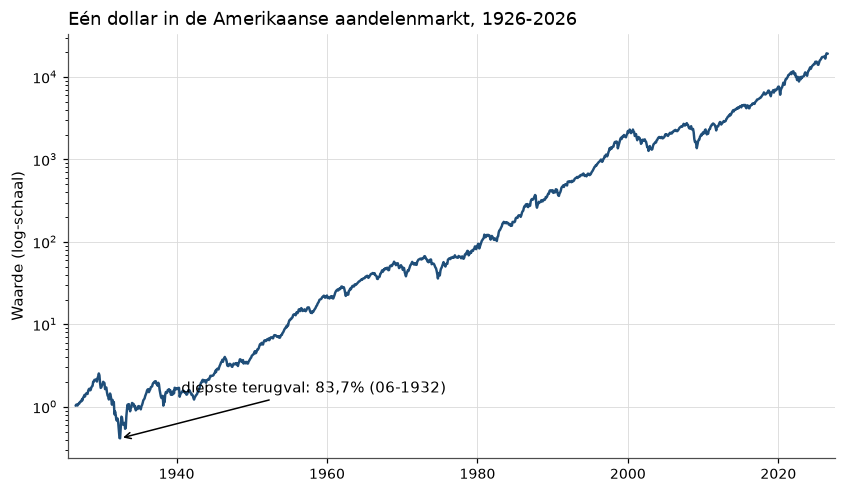

In [3]:
wealth = hap.drawdowns(market["Mkt"])
worst_date = wealth["drawdown"].idxmin()
worst_drop = -wealth["drawdown"].min()

fig, ax = plt.subplots()
ax.plot(wealth.index, wealth["wealth"])
ax.annotate(
    f"diepste terugval: {number_nl(100 * worst_drop)}% ({worst_date:%m-%Y})",
    xy=(worst_date, wealth.loc[worst_date, "wealth"]),
    xytext=(40, 30), textcoords="offset points",
    arrowprops={"arrowstyle": "->"},
)
ax.set_yscale("log")
ax.set_title("Eén dollar in de Amerikaanse aandelenmarkt, 1926-2026")
ax.set_xlabel("Jaar")
ax.set_ylabel("Waarde (log-schaal)")
hap.plotting.timeline_axis(ax)
plt.show()

:::{figure} #cel-setup-french
:label: fig-setup-french
:width: 90%

Cumulatieve waarde van één dollar, herbelegd in de value-weighted markt. Op een
log-schaal zijn gelijke procentuele bewegingen even groot. Op een lineaire schaal
zou alles vóór 1980 een vlakke lijn zijn. De diepste terugval is 83,7%, met het
dieptepunt in juni 1932.
:::

### Robert Shiller: prijzen en dividenden, 1871–

De maandreeks van Shiller gaat een halve eeuw verder terug dan French. Ze bevat
naast de prijs ook het dividend, de winst, de consumentenprijsindex en de lange
rente {cite}`Shiller2000`. Daarmee koppelen we prijzen aan *fundamentals*
(dividenden en winsten), en niet alleen aan elkaar. Dat is nodig voor alles wat
met waardering en voorspelbaarheid te maken heeft. De bekendste afgeleide reeks
is de CAPE: de prijs gedeeld door het tienjaarsgemiddelde van de reële winst.

We tonen de eerste en de laatste maand waarin alle vijf kolommen bekend zijn.

In [4]:
shiller = hap_data.shiller()
shiller[["price", "dividend", "earnings", "cape", "dp"]].dropna().iloc[[0, -1]].round(3)

,price,dividend,earnings,cape,dp
date,,,,,
1881-01-31,6.190,0.265,0.486,18.474,0.043
2026-06-30,7450.033,81.703,295.388,40.150,0.011


Tussen 1881 en 2026 steeg de CAPE van 18,5 naar 40,2, en het dividendrendement
(kolom `dp`, hier $D/P$ in niveaus) daalde van 4,3% naar 1,1%. De figuur toont
de hele CAPE-reeks met haar gemiddelde als stippellijn. De vraag bij het kijken:
hoe lang blijft de reeks boven of onder die lijn?

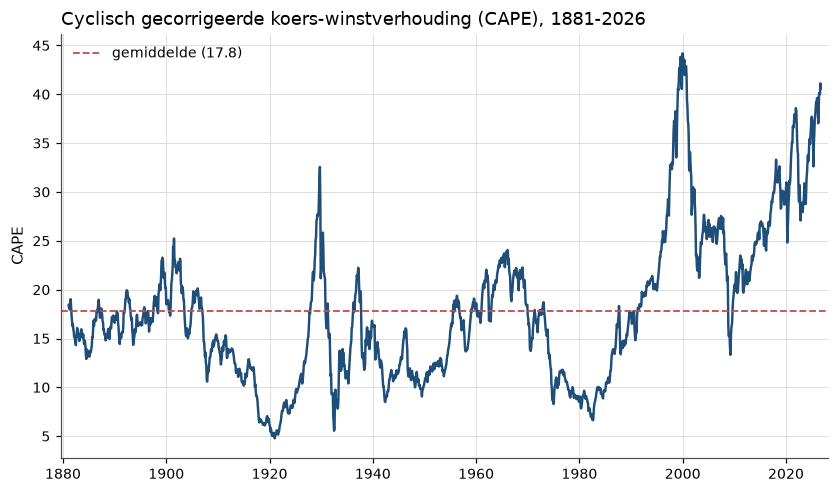

In [5]:
cape = shiller["cape"].dropna()

fig, ax = plt.subplots()
ax.plot(cape.index, cape)
ax.axhline(cape.mean(), color=hap.plotting.COLORS[1], ls="--", lw=1.2,
           label=f"gemiddelde ({cape.mean():.1f})")
ax.set_title("Cyclisch gecorrigeerde koers-winstverhouding (CAPE), 1881-2026")
ax.set_xlabel("Jaar")
ax.set_ylabel("CAPE")
ax.legend()
hap.plotting.timeline_axis(ax)
plt.show()

:::{figure} #cel-setup-shiller
:label: fig-setup-shiller
:width: 90%

De CAPE schommelt over decennia rond een gemiddelde van ongeveer 17,8 en staat
aan het eind van de steekproef op ruim 40. Betekent zo'n hoge waarde een lage
discontovoet of een te hoge prijs? Over die vraag werden Fama en Shiller het niet
eens.
:::

### Goyal-Welch: de voorspellers

Welch en Goyal verzamelden de variabelen waarmee de literatuur de equity premium
probeerde te voorspellen. Voorbeelden zijn het dividendrendement, de
termijnspread en de netto aandelenuitgifte. Ze toonden dat vrijwel geen ervan
buiten de steekproef beter voorspelt dan het historisch gemiddelde
{cite}`GoyalWelch2008`. Hun dataset wordt bijgehouden en loopt vanaf 1871.

De laatste drie jaarrijen laten zien hoe de kolommen heten en in welke eenheden
ze staan.

In [6]:
gw = hap_data.goyal_welch("annual")
gw[["Index", "D12", "E12", "tbl", "dp", "tms", "equity_premium"]].tail(3).round(4)

,Index,D12,E12,tbl,dp,tms,equity_premium
date,,,,,,,
2023-12-31,4769.8300,70.3037,192.43,0.0524,-4.2172,-0.0122,0.1879
2024-12-31,5881.6276,74.8323,210.17,0.0427,-4.3643,0.0012,0.1773
2025-12-31,6845.5000,78.9202,246.47,0.0359,-4.4629,0.0055,0.1247


Let op: in deze dataset is `dp` het log dividendrendement, $\log(D/P)$, dus
een negatief getal rond $-4{,}4$. `D12` en `E12` zijn dividend en winst over
twaalf maanden, `tbl` de rente op schatkistpapier, `tms` de termijnspread.
`equity_premium` is het excess rendement op de markt in dat jaar. In de figuur
gaat het om de traagheid van `dp`: beweegt de lijn over jaren of over decennia?

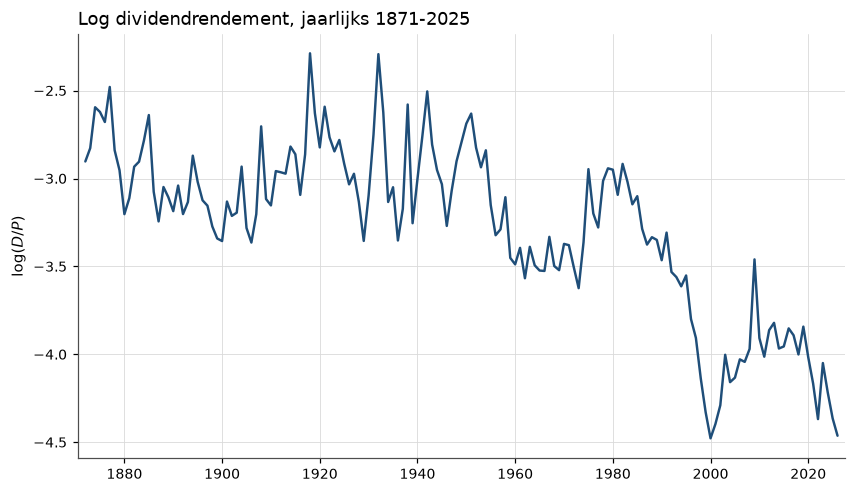

In [7]:
fig, ax = plt.subplots()
ax.plot(gw.index, gw["dp"])
ax.set_title("Log dividendrendement, jaarlijks 1871-2025")
ax.set_xlabel("Jaar")
ax.set_ylabel("$\\log(D/P)$")
hap.plotting.timeline_axis(ax)
plt.show()

:::{figure} #cel-setup-gw
:label: fig-setup-gw
:width: 90%

Het log dividendrendement is extreem persistent: het beweegt over decennia, niet
over jaren. Daardoor lijdt een regressie met deze voorspeller aan de
Stambaugh-bias {cite}`Stambaugh1999`. Een stijgende koers verhoogt het rendement
en verlaagt tegelijk $D/P$. Omdat de persistentie in een korte steekproef te laag
wordt geschat, is de helling naar boven vertekend en de $t$-waarde te groot. Dat
geldt ook voor de regressie verderop in deze lecture.
:::

### FRED: de macrocontext

FRED, van de Federal Reserve Bank of St. Louis, levert alles wat de markt
omringt: consumptie, inflatie, rentes, wisselkoersen, credit spreads en de VIX.
Ook de NBER-recessie-indicator komt uit FRED; `hap.plotting.recession_shading`
tekent daarmee grijze banden in een figuur. De loader haalt één serie per
aanroep, in de eenheden van FRED.

Als voorbeeld laden we de VIX, de door de optiemarkt verwachte volatiliteit van
de S&P 500 over de komende maand, in procenten per jaar.

In [8]:
vix = hap_data.fred("VIXCLS")
vix.describe().round(2)

,VIXCLS
count,9266.00
mean,19.43
std,7.72
min,9.14
25%,13.99
50%,17.58
75%,22.68
max,82.69


Over 9266 handelsdagen sinds 1990 ligt de mediaan van de VIX op 17,6 en het
maximum op 82,7. In de figuur is te zien of de pieken samenvallen met de grijze
recessiebanden.

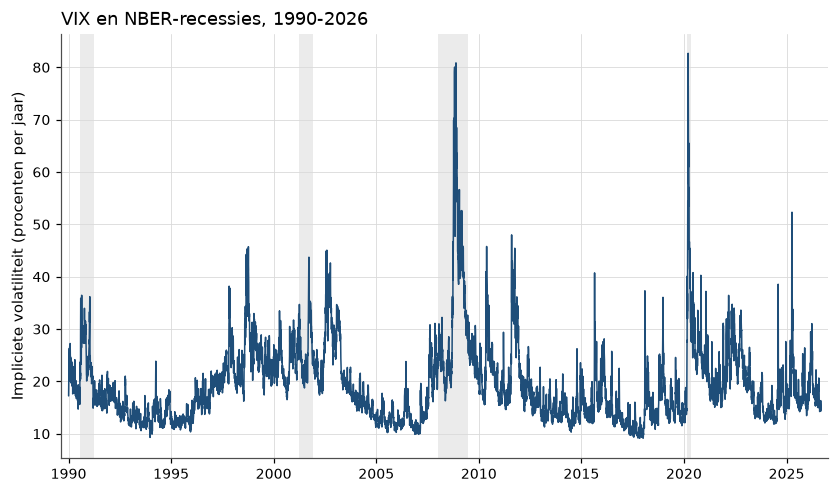

In [9]:
series = vix["VIXCLS"].dropna()

fig, ax = plt.subplots()
ax.plot(series.index, series, lw=1.0)
ax.set_title("VIX en NBER-recessies, 1990-2026")
ax.set_xlabel("Jaar")
ax.set_ylabel("Impliciete volatiliteit (procenten per jaar)")
hap.plotting.timeline_axis(ax)
hap.plotting.recession_shading(ax)
plt.show()

:::{figure} #cel-setup-fred
:label: fig-setup-fred
:width: 90%

De VIX piekt in recessies (grijs), maar niet alleen daar. Oktober 2008 en maart
2020 springen eruit, en 1998 en 2018 zijn ook zichtbaar. Anders dan het
gemiddelde rendement clustert volatiliteit zichtbaar, en daarom is ze
voorspelbaar.
:::

### Gürkaynak-Sack-Wright: de yieldcurve

De Federal Reserve publiceert dagelijks een geschatte zero-coupon yieldcurve,
terug tot 1961 {cite}`GurkaynakSackWright2007`. `hap.gsw()` geeft de kolommen
`SVENYnn` (zero-coupon yield op $nn$ jaar), `SVENFnn` (instantane forward) en de
onderliggende parameters, alles als decimalen.

We kiezen drie dagen die het bereik van de reeks laten zien en tonen de yield op
één, vijf en tien jaar.

In [10]:
gsw = hap_data.gsw()
gsw.loc[["1981-09-30", "2020-08-04", "2026-08-28"], ["SVENY01", "SVENY05", "SVENY10"]].round(4)

,SVENY01,SVENY05,SVENY10
date,,,
1981-09-30,0.1569,0.1518,0.1489
2020-08-04,0.0013,0.0022,0.0052
2026-08-28,0.0420,0.0448,0.0480


In september 1981 was de eenjaarsrente 15,7%, in augustus 2020 was ze 0,13%. De
figuur tekent voor dezelfde drie dagen de hele curve tot dertig jaar. Kijk naar
de vorm: daalt, stijgt of vlakt de curve af met de looptijd?

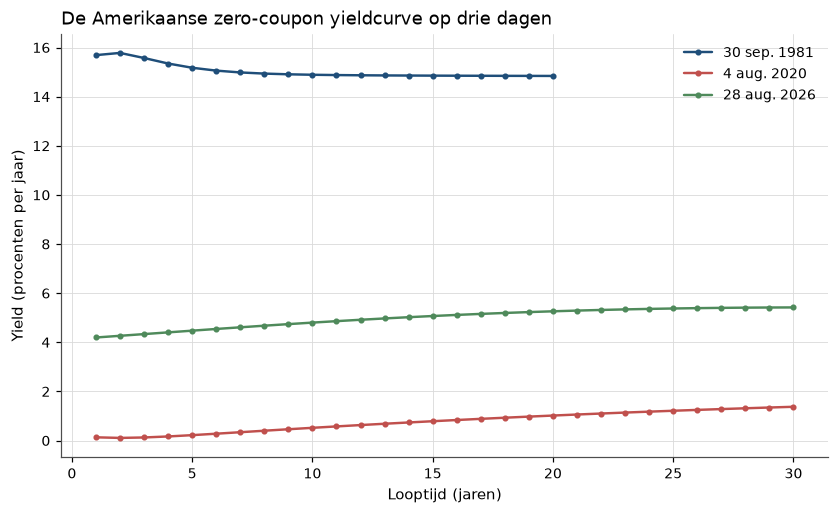

In [11]:
maturities = [f"SVENY{n:02d}" for n in range(1, 31)]

fig, ax = plt.subplots()
for date, label in [("1981-09-30", "30 sep. 1981"),
                    ("2020-08-04", "4 aug. 2020"),
                    ("2026-08-28", "28 aug. 2026")]:
    curve = gsw.loc[date, maturities].dropna()
    ax.plot(range(1, len(curve) + 1), curve.to_numpy() * 100, marker="o",
            ms=3, label=label)
ax.set_title("De Amerikaanse zero-coupon yieldcurve op drie dagen")
ax.set_xlabel("Looptijd (jaren)")
ax.set_ylabel("Yield (procenten per jaar)")
ax.legend()
plt.show()

:::{figure} #cel-setup-gsw
:label: fig-setup-gsw
:width: 90%

In 1981 daalt de curve met de looptijd, in 2020 stijgt ze vanaf bijna nul,
en in 2026 loopt ze licht op. Een steile curve gaat vaak vooraf aan hoge
rendementen op lange obligaties. Ook daar is de vraag risico of vergissing.
:::

### Open Source Asset Pricing: de factor zoo, gedocumenteerd

Chen en Zimmermann bouwden de gepubliceerde cross-sectionele anomalieën na
volgens de recepten van de originele papers {cite}`ChenZimmermann2022`. Een
anomalie, in de data een signaal of voorspeller genoemd, is een kenmerk van
aandelen dat gemiddelde rendementen lijkt te voorspellen, bijvoorbeeld de
accruals van een bedrijf. Per signaal publiceerden Chen en Zimmermann het
long-short-rendement: de portefeuille met de hoogste waarden van het kenmerk min
die met de laagste. Een documentatiebestand geeft per signaal de auteurs, het publicatiejaar en de gerapporteerde
$t$-waarde. Daarmee is na te gaan of factoren na publicatie blijven werken.

We laden het documentatiebestand en tonen de eerste vijf voorspellers.

In [12]:
signaldoc = hap_data.osap("signaldoc")
predictors = signaldoc[signaldoc["Cat.Signal"] == "Predictor"]
predictors[["signal", "Authors", "Year", "Journal", "T-Stat"]].head(5)

,signal,Authors,Year,Journal,T-Stat
date,,,,,
2001-12-31,AbnormalAccruals,Xie,2001,AR,8.43
1996-12-31,Accruals,Sloan,1996,AR,4.71
2004-12-31,AccrualsBM,Bartov and Kim,2004,RFQA,5.50
2005-12-31,Activism1,Cremers and Nair,2005,JF,3.13
1992-12-31,AM,Fama and French,1992,JF,5.69


Elke rij is één gepubliceerd signaal, met de $t$-waarde uit het originele paper.
De figuur telt de signalen cumulatief per publicatiejaar, en de legenda geeft de
mediane gepubliceerde $t$-waarde. Rond welk jaar wordt de lijn steil?

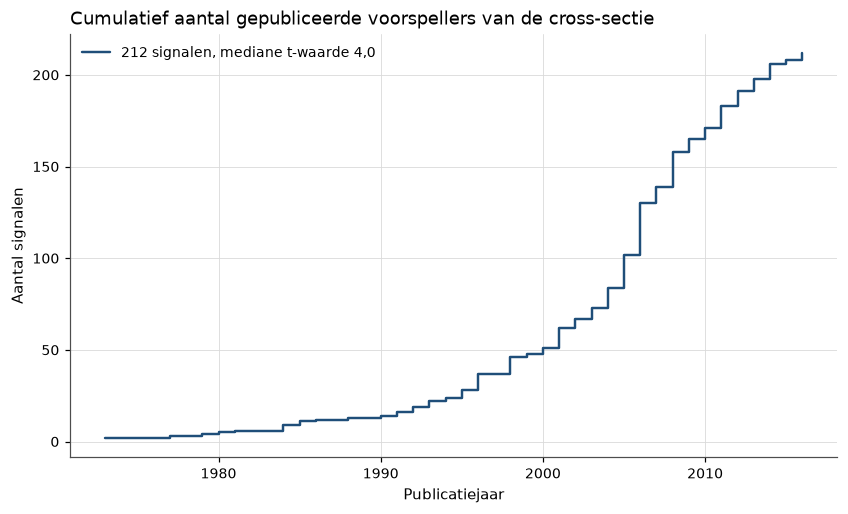

In [13]:
per_year = predictors.index.year.value_counts().sort_index()
median_t = predictors["T-Stat"].median()

fig, ax = plt.subplots()
ax.step(per_year.index, per_year.cumsum(), where="post",
        label=f"{len(predictors)} signalen, mediane t-waarde {number_nl(median_t)}")
ax.set_title("Cumulatief aantal gepubliceerde voorspellers van de cross-sectie")
ax.set_xlabel("Publicatiejaar")
ax.set_ylabel("Aantal signalen")
ax.legend()
plt.show()

:::{figure} #cel-setup-osap
:label: fig-setup-osap
:width: 90%

Van een handvol anomalieën in de jaren zeventig naar 212 gereproduceerde
signalen. De mediane gepubliceerde $t$-waarde is 4,0, ruim boven de gebruikelijke
drempel van 1,96. Dat is geen toeval maar een selectie-effect: wat niet
significant was, werd niet gepubliceerd {cite}`HarveyLiuZhu2016`.
:::

### He-Kelly-Manela: het kapitaal van de tussenpersoon

Na 2008 kwam er een klasse modellen waarin niet de gemiddelde belegger de prijzen
zet, maar de gefinancierde tussenpersoon: de dealer, de hedgefondsdesk, de bank.
He, Kelly en Manela construeerden de kapitaalratio van de primary dealers, de
grote banken die rechtstreeks met de Federal Reserve handelen. Ze lieten zien dat
schokken in die ratio de gemiddelde rendementen in veel activaklassen tegelijk
verklaren {cite}`HeKellyManela2017`.

We tonen de laatste drie maanden van de vier kolommen.

In [14]:
hkm = hap_data.hkm("monthly")
hkm.tail(3).round(4)

,intermediary_capital_ratio,intermediary_capital_risk_factor,intermediary_value_weighted_investment_return,intermediary_leverage_ratio_squared
date,,,,
2025-03-31,0.0745,-0.0944,-0.0661,180.2846
2025-04-30,0.0739,-0.0051,-0.0092,183.3444
2025-05-31,0.0791,0.0742,0.0833,159.8318


De kapitaalratio stond in het voorjaar van 2025 rond 7,5%. De figuur toont de hele
reeks sinds 1970; let op het laagste punt en de recessie waarin het valt.

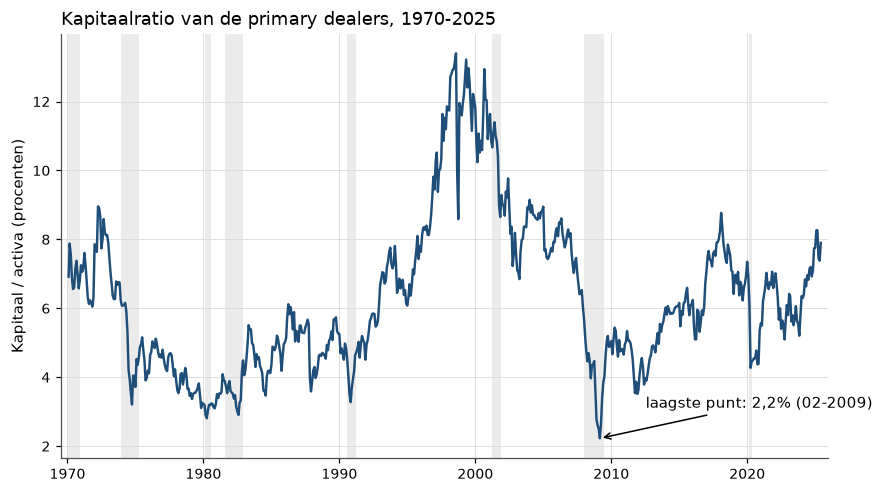

In [15]:
ratio = hkm["intermediary_capital_ratio"]
low_date = ratio.idxmin()

fig, ax = plt.subplots()
ax.plot(ratio.index, ratio * 100)
ax.annotate(
    f"laagste punt: {number_nl(100 * ratio.min())}% ({low_date:%m-%Y})",
    xy=(low_date, ratio.min() * 100),
    xytext=(30, 20), textcoords="offset points",
    arrowprops={"arrowstyle": "->"},
)
ax.set_title("Kapitaalratio van de primary dealers, 1970-2025")
ax.set_xlabel("Jaar")
ax.set_ylabel("Kapitaal / activa (procenten)")
hap.plotting.timeline_axis(ax)
hap.plotting.recession_shading(ax)
plt.show()

:::{figure} #cel-setup-hkm
:label: fig-setup-hkm
:width: 90%

De kapitaalratio van de tussenpersonen bereikt haar laagste punt in februari
2009, op 2,2%. In modellen van intermediary asset pricing is dat de
toestandsvariabele: daalt het kapitaal van de dealer ten opzichte van zijn
activa, dan stijgt de vergoeding die hij eist voor elk risico dat hij draagt.
Dat is de risico-lezing van een crash; de vergissing-lezing ziet dezelfde lage
prijzen als paniek.
:::

### Yahoo Finance: recente koersen en optieketens

Voor dagkoersen van afzonderlijke effecten, zoals in event studies en bij
optieketens, gebruiken we Yahoo Finance via `yfinance`. De cache bevat voor
splitsingen en dividenden gecorrigeerde slotkoersen van de vijf ETF's hieronder,
van vijftig afzonderlijke aandelen, van twee groepen beleggingsfondsen (59 en 8
fondsen), van enkele indexreeksen,
en twee momentopnamen van de optieketen van SPY. Yahoo is de enige onbetrouwbare bron in
de lijst: downloads komen soms leeg terug. Een lecture vraagt daarom alleen op
wat al in de cache staat.

De ETF-reeks begint in 1993, maar pas vanaf eind 2004 bestaan alle vijf de ETF's. We
nemen daarom 2005 en later, en tonen per ETF het gemiddelde rendement per jaar,
berekend uit dagrendementen, met zijn standaardfout.

In [16]:
etf = hap_data.yahoo(["SPY", "TLT", "GLD", "QQQ", "IWM"], "1993-01-01")
recent = etf.loc["2005-01-01":].dropna()
daily_returns = recent.pct_change().dropna()

etf_stats = hap.summary_stats(daily_returns, "daily")
etf_stats[["mean_ann", "std_ann", "se_mean_ann"]].rename(columns=columns_nl).round(3)

,gemiddelde (per jaar),volatiliteit (per jaar),standaardfout gemiddelde
GLD,0.120593,0.182721,0.039284
IWM,0.11294,0.240037,0.051606
QQQ,0.164993,0.216205,0.046482
SPY,0.121899,0.189033,0.040641
TLT,0.039764,0.145439,0.031268


De standaardfouten liggen tussen 3 en 5 procentpunt. SPY, GLD en IWM liggen minder
dan één procentpunt uit elkaar, QQQ en TLT liggen 12,5 procentpunt uit elkaar. In
de figuur, met elke reeks op 1 gezet in 2005, is de vraag welke verschillen tussen
de lijnen groter zijn dan die ruis.

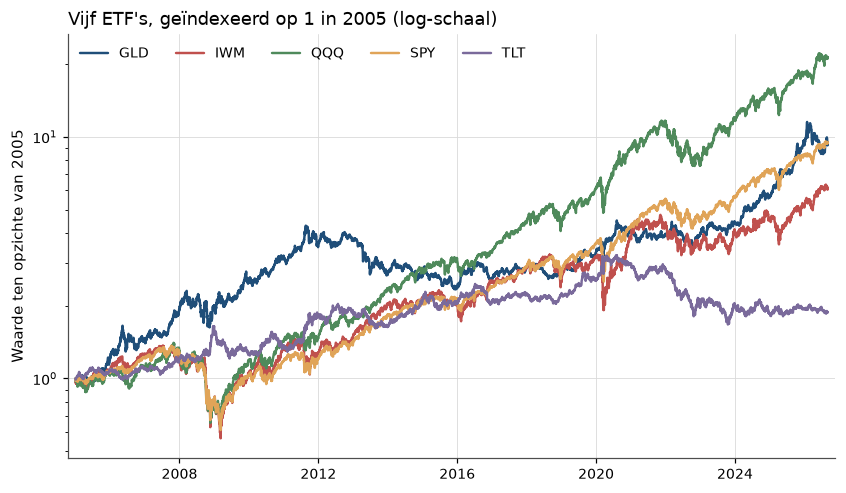

In [17]:
normalised = recent / recent.iloc[0]

fig, ax = plt.subplots()
for column in normalised.columns:
    ax.plot(normalised.index, normalised[column], label=column)
ax.set_yscale("log")
ax.set_title("Vijf ETF's, geïndexeerd op 1 in 2005 (log-schaal)")
ax.set_xlabel("Jaar")
ax.set_ylabel("Waarde ten opzichte van 2005")
ax.legend(ncols=5)
hap.plotting.timeline_axis(ax)
plt.show()

:::{figure} #cel-setup-yahoo
:label: fig-setup-yahoo
:width: 90%

Aandelen (SPY, QQQ, IWM), langlopende staatsobligaties (TLT) en goud (GLD) vanaf
2005. Na twintig jaar is de standaardfout van elk gemiddelde 3 tot 5 procentpunt.
Alleen grote verschillen, zoals QQQ tegen TLT (12,5 procentpunt), steken daar
boven uit. SPY, GLD en IWM eindigen verschillend, maar hun gemiddelden liggen
binnen één procentpunt: dat verschil verdwijnt in de ruis.
:::

### Wat we niet hebben: CRSP en Compustat

Twee databanken komen in deze reeks voortdurend voor, zonder dat we ze ooit
openen.

*CRSP* is het Center for Research in Security Prices van de Universiteit van
Chicago. Vanaf 1960 bouwde het, met geld van Merrill Lynch, de eerste
machineleesbare reeks maandrendementen van alle aandelen op de New York Stock
Exchange, terug tot 1926. De reeks bevat dividenden, splitsingen en ook de
aandelen die van de beurs verdwenen. Zonder die laatste groep meet een
onderzoeker alleen de overlevenden. De eerste publicatie op die tape
{cite}`FisherLorie1964` was de eerste betrouwbare meting van het gemiddelde
rendement op Amerikaanse aandelen over een lange periode. De databank
*Compustat* doet hetzelfde voor de boekhouding: balans en resultatenrekening per bedrijf per
kwartaal, en daarmee de noemer van elke waarderingsratio.

Beide zijn commercieel en duur, en meestal alleen via een universiteitsabonnement
toegankelijk. Deze reeks gebruikt ze niet. Dat kost iets: we kunnen niets doen op
het niveau van het individuele aandeel. Geen eigen sorteringen, geen eigen
portefeuilles, geen event study op een brede steekproef. In ruil draait elke
lecture op een laptop zonder abonnement.

De belangrijkste bewerkingen zijn al voor ons gedaan. Kenneth French publiceert
de portefeuilles die uit CRSP en Compustat zijn gebouwd, en Chen en Zimmermann
publiceren de long-short-rendementen van de anomalieën. We erven daarmee hun
constructiekeuzes, en waar dat uitmaakt, staat het in het replicatieblok. Waar
zelfs dat niet volstaat, simuleren we. Dan staat erbij welke eigenschap van de
echte data de simulatie nabootst.

Uit de acht figuren nemen we drie dingen mee. Gemiddelde rendementen zijn slecht
bekend, over een eeuw (French) en zeker over twintig jaar (Yahoo). De traag
bewegende grootheden, zoals de CAPE, het dividendrendement en de kapitaalratio,
zijn de voorspellers waar risico of vergissing om draait. En de factor zoo is
voor een deel een selectie-effect van de standaardfout van 2%.

## De gereedschapskist: `hap.stats` en `hap.plotting`

Naast de loaders bevat `hap` twee kleine modules. In `hap.stats` staan de
standaardschatters van deze literatuur: `newey_west` (OLS met standaardfouten die
autocorrelatie toelaten), `fama_macbeth`, `grs_test`, `long_horizon_regression`,
`variance_ratio`, `hansen_jagannathan_bound`, `sharpe`, `drawdowns` en
`summary_stats`. Ze werken op gewone pandas-objecten en verwachten rendementen als
decimalen per periode.

Een voorbeeld: voorspelt het log dividendrendement het rendement van het
volgende jaar? We regresseren de equity premium van jaar $t+1$ op
$\mathrm{dp}_t$, met Newey-West-standaardfouten en één vertraging.

In [18]:
panel = pd.DataFrame(
    {"ep_next": gw["equity_premium"].shift(-1), "dp": gw["dp"]}
).dropna()
fit = hap.newey_west(panel["ep_next"], panel[["dp"]], lags=1)

pd.DataFrame(
    {"coëfficiënt": fit.params, "standaardfout": fit.bse, "t-waarde": fit.tvalues}
).round(4)

,coëfficiënt,standaardfout,t-waarde
const,0.2103,0.1580,1.3307
dp,0.0423,0.0444,0.9526


De helling is 0,042 en positief: een hoog dividendrendement gaat samen met een
hoger rendement daarna. Dat teken voorspelt de theorie van discontovoeten die in
de tijd variëren. Een hoog $D/P$ is een lage prijs ten opzichte van het dividend,
en een lage prijs betekent een hoog verwacht rendement. Maar met een $t$-waarde
van 0,95 bewijst de regressie niets. Er zijn honderd jaarobservaties, niet 155,
omdat `equity_premium` pas in 1926 begint. Die spanning, tussen een teken dat klopt en een standaardfout
die te groot is, komt in een groot deel van de reeks terug.

`hap.plotting` is kleiner. `setup()` zet de projectstijl en staat in de
imports-cel. `timeline_axis(ax)` maakt van een datum-as een as in kalenderjaren.
`recession_shading(ax)` zet de NBER-recessies als grijze banden achter een
figuur, en `COLORS` is het vaste kleurenpalet. Elke figuur heeft een titel en
aslabels in het Nederlands.

## Werken met de code

Het project wordt beheerd met `uv`. Alle Python-commando's lopen via `uv run`,
dat de virtuele omgeving en de afhankelijkheden uit `pyproject.toml` op orde
houdt. De testsuite draait offline:

```bash
uv run pytest -q
```

Elke lecture bestaat twee keer: als MyST-markdown (`lectures/00_00_setup.md`) en
als notebook (`lectures/00_00_setup.ipynb`). Jupytext houdt de twee gepaard. De
markdown is de bron voor de tekst, het notebook de plek om code uit te proberen.
Wie in het notebook werkt, synchroniseert terug en voert de lecture opnieuw uit:

```bash
uv run jupytext --sync lectures/00_00_setup.md
uv run jupytext --execute --to ipynb lectures/00_00_setup.md
```

Voor de data zijn er twee omgevingsvariabelen. `HAP_OFFLINE=1` verbiedt elke
download: de loaders lezen alleen uit `data/cache/`. Een ontbrekende snapshot
geeft dan een `hap.CacheMissError`, in plaats van stilzwijgend nieuwe data. Zo
draait de testsuite, en zo is elke lecture uitgevoerd. `HAP_REFRESH=1` doet het
omgekeerde en haalt een verse snapshot op. Zonder een van beide wordt alleen
gedownload als het parquet-bestand ontbreekt. Snapshots verlopen dus nooit
vanzelf, en een figuur van vandaag ziet er morgen hetzelfde uit.

```{warning}
Een reeks die per uitvoering verandert, is niet reproduceerbaar. Ververs een
snapshot bewust, met `HAP_REFRESH=1` en een aantekening erbij, en niet als
bijvangst van een lecture die toevallig wordt uitgevoerd.
```

## Een eerste meting: het gemiddelde en zijn standaardfout

*Waarom zou dit waar zijn?* Een onderzoeker die een eeuw jaarrendementen
middelt, heeft honderd trekkingen uit een verdeling met een klein midden en een
grote spreiding. Een typisch jaar wijkt ongeveer 20 procentpunt af van het
midden, terwijl dat midden, het excess rendement, maar ongeveer 8% is. Meer jaren
maken de schatting beter, maar traag: de fout daalt met de wortel van het aantal
jaren. Hoe fijn de onderzoeker binnen een jaar kijkt, helpt voor het gemiddelde
niet. We verwachten dus een standaardfout die na een eeuw nog een flink deel van
het gemiddelde zelf is.

De formule achter die verwachting is de standaardfout van een steekproefgemiddelde
van $T$ onafhankelijke trekkingen met standaarddeviatie $\sigma$:
$\SD(\bar r) = \sigma/\sqrt{T}$. Met $\sigma = 20\%$ en $T = 100$ is dat 2
procentpunt, de naam van het motief. Voor de geschatte volatiliteit geldt bij
normale rendementen $\SD(\hat\sigma) \approx \sigma/\sqrt{2T} = 0{,}20/\sqrt{200}
= 1{,}4$ procentpunt; oefening 2 leidt die formule af.

We simuleren een markt met een werkelijk gemiddeld excess rendement van 8% en een
werkelijke volatiliteit van 20% per jaar, honderd jaar lang. De 8% ligt dicht
bij de 8,3% van `Mkt-RF` in de eerste tabel; de 20% is een ronde kalibratie, iets
boven de gemeten 18,4%. We kijken wat
één zo'n eeuw schat.

In [19]:
mu_true, sigma_true, n_years = 0.08, 0.20, 100
one_century = rng.normal(mu_true, sigma_true, n_years)

mean_hat = one_century.mean()
se_hat = one_century.std(ddof=1) / np.sqrt(n_years)

pd.DataFrame(
    {
        "waarde": [mu_true, mean_hat, se_hat, mean_hat - 1.96 * se_hat,
                   mean_hat + 1.96 * se_hat],
    },
    index=["werkelijk gemiddelde", "geschat gemiddelde", "standaardfout",
           "ondergrens 95%", "bovengrens 95%"],
).round(4)

,waarde
werkelijk gemiddelde,0.0800
geschat gemiddelde,0.0846
standaardfout,0.0203
ondergrens 95%,0.0449
bovengrens 95%,0.1243


Deze eeuw schat 8,5% met een standaardfout van 2,0 procentpunt. Het 95%-interval
loopt van 4,5% tot 12,4%, en het werkelijke gemiddelde ligt erin.

Eén steekproef zegt weinig. We simuleren daarom tienduizend eeuwen en zetten de
spreiding van beide schatters naast de formules.

In [20]:
n_sim = 10_000
samples = rng.normal(mu_true, sigma_true, size=(n_sim, n_years))
means = samples.mean(axis=1)
sds = samples.std(axis=1, ddof=1)

se_mean_formula = sigma_true / np.sqrt(n_years)
se_sd_formula = sigma_true / np.sqrt(2 * n_years)

pd.DataFrame(
    {
        "formule": [se_mean_formula, se_sd_formula],
        "simulatie": [means.std(ddof=1), sds.std(ddof=1)],
        "relatieve fout (simulatie)": [means.std(ddof=1) / mu_true,
                                       sds.std(ddof=1) / sigma_true],
    },
    index=["standaardfout gemiddelde", "standaardfout volatiliteit"],
).round(4)

,formule,simulatie,relatieve fout (simulatie)
standaardfout gemiddelde,0.0200,0.0200,0.2498
standaardfout volatiliteit,0.0141,0.0142,0.0709


Formule en simulatie komen overeen: 2,0 procentpunt voor het gemiddelde, 1,4 voor
de volatiliteit. Relatief is het verschil groot. Het gemiddelde heeft een
relatieve fout van ongeveer 25%, de volatiliteit van ongeveer 7%. Na een eeuw is
de volatiliteit dus op een paar procent na bekend, het gemiddelde op een kwart na.
De figuur toont de hele verdeling van het geschatte gemiddelde, met de
95%-grenzen als stippellijnen.

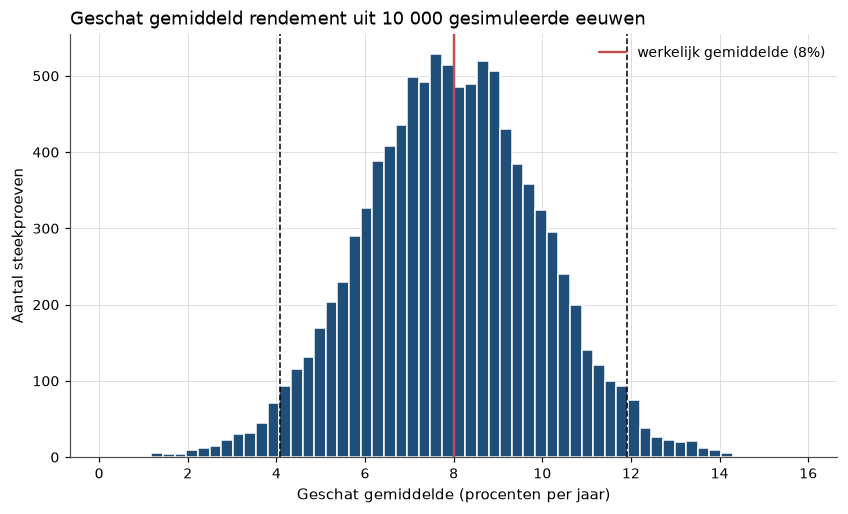

In [21]:
fig, ax = plt.subplots()
ax.hist(means * 100, bins=60, edgecolor="white")
ax.axvline(mu_true * 100, color=hap.plotting.COLORS[1], lw=1.6,
           label="werkelijk gemiddelde (8%)")
for side in (-1, 1):
    ax.axvline((mu_true + side * 1.96 * sigma_true / np.sqrt(n_years)) * 100,
               color="black", ls="--", lw=1.0)
ax.set_title("Geschat gemiddeld rendement uit 10 000 gesimuleerde eeuwen")
ax.set_xlabel("Geschat gemiddelde (procenten per jaar)")
ax.set_ylabel("Aantal steekproeven")
ax.legend()
plt.show()

:::{figure} #cel-setup-se
:label: fig-setup-se

De verdeling van het gemiddelde rendement over tienduizend gesimuleerde eeuwen.
De stippellijnen liggen twee standaardfouten van de waarheid af, op ongeveer 4%
en 12%. Een onderzoeker met honderd jaar data en een perfect gespecificeerd model
weet dus nog steeds niet of de premie 4% of 12% is.
:::

Zoals verwacht is het gemiddelde na een eeuw nog slecht bekend, en de
volatiliteit goed. De asymmetrie komt uit de verhouding $\sigma/\mu$: bij 20%
tegen 8% is de ruis van één jaar 2,5 keer zo groot als het signaal. Meer jaren
helpen beide, fijnere data helpt alleen de variantie. Voor het gemiddelde
logrendement is de reden exact. Dat is het logverschil tussen eind- en
beginkoers, gedeeld door de lengte van de periode, en de koersen daartussen
tellen niet mee. Het rekenkundig gemiddelde ligt ongeveer een halve variantie
hoger en is dus even slecht gemeten. De variantie daarentegen is een gemiddelde
van gekwadrateerde rendementen, en wordt scherper met elke extra waarneming.

De regressie in de gereedschapskist was een tweede geval van hetzelfde motief:
een helling van 0,042 met een standaardfout van 0,044.

```{admonition} Replicatie
:class: seealso

**Bron.** Geen paper, maar de rekensom achter de standaardfout van 2%: de
formule $\sigma/\sqrt{T}$ en de simulatie hierboven.

**Wat.** De standaardfout van het gemiddelde excess rendement op de Amerikaanse
aandelenmarkt over een eeuw.

**Data hier.** `Mkt-RF` uit de Kenneth French Data Library, 1201 maanden vanaf
juli 1926: de reeks die de simulatie nabootst.

**Verschil met de simulatie.** De echte volatiliteit is 18,4% in plaats van 20%.
Maandrendementen zijn niet onafhankelijk en niet normaal: ze hebben lichte
autocorrelatie en dikke staarten.

**Verwachte afwijking.** Met 18,4% geeft de formule ongeveer 1,8 procentpunt in
plaats van 2,0. Autocorrelatie kan een standaardfout die daar rekening mee houdt
enkele tienden hoger maken. De orde van grootte, tussen 1,5 en 2,5 procentpunt,
moet kloppen.
```

We zetten simulatie en data naast elkaar. Voor de data berekenen we de
standaardfout op twee manieren: met de formule, en met Newey-West over twaalf
maanden, die autocorrelatie toelaat.

In [22]:
excess_monthly = market["Mkt-RF"]
excess_stats = market_stats.loc["Mkt-RF"]

constant = pd.Series(1.0, index=excess_monthly.index, name="gemiddelde")
nw_fit = hap.newey_west(excess_monthly, constant, lags=12, add_constant=False)
se_newey_west = 12 * nw_fit.bse["gemiddelde"]  # monthly to annual

pd.DataFrame(
    {
        "simulatie (8%, 20%)": [mu_true, sigma_true, se_mean_formula, means.std(ddof=1)],
        "data (Mkt-RF)": [excess_stats["mean_ann"], excess_stats["std_ann"],
                          excess_stats["se_mean_ann"], se_newey_west],
    },
    index=["gemiddelde", "volatiliteit", "standaardfout, formule",
           "standaardfout, spreiding of Newey-West"],
).round(4)

,"simulatie (8%, 20%)",data (Mkt-RF)
gemiddelde,0.08,0.0833
volatiliteit,0.20,0.1837
"standaardfout, formule",0.02,0.0184
"standaardfout, spreiding of Newey-West",0.02,0.0197


**Geslaagd.** Op de data geeft de formule 1,8 procentpunt en Newey-West 2,0,
binnen de verwachte afwijking van enkele tienden. Het gemiddelde excess rendement
van 8,3% is dus op ongeveer 2 procentpunt na bekend. Het totale marktrendement
`Mkt` heeft dezelfde standaardfout, 1,8 procentpunt bij 11,6%, omdat de
risicovrije rente nauwelijks schommelt. De standaardfout van 2% is geen metafoor,
maar een rekensom die hier drie keer is gemaakt.

## Wat er daarna komt

De gereedschapskist staat klaar: acht databronnen die offline draaien, een
notatie voor de hele reeks, en een handvol schatters. Wat nog ontbreekt, is het
begrip waar alles op rust. In deze lecture zijn rendementen opgeteld, gemiddeld en
geannualiseerd zonder te zeggen wat een rendement is. Open bleef ook of het
meetkundig of het rekenkundig gemiddelde de gestelde vraag beantwoordt. En de
bewering dat dagdata de variantie scherper maakt en het gemiddelde niet, staat
hier zonder bewijs.

Dat is de inhoud van [Rendementen en hun statistiek](#00-01-rendementen):
logrendementen en simpele rendementen, annualisatie, de standaardfout van het
gemiddelde in volle vorm, autocorrelatie en dikke staarten. Daarna begint het
verhaal in 1863, bij een man in Parijs die zag dat de koersuitslag met de wortel
van de tijd toenam.

## Oefeningen

:::{exercise}
:label: ex-setup-1

**Een loader gebruiken en een grootheid berekenen.** Laad de tien
industrieportefeuilles van French met
`hap_data.french("10_Industry_Portfolios", "monthly")` en beperk de steekproef
tot 1970 en later.

1. Bereken per industrie het geannualiseerde gemiddelde rendement, de
   geannualiseerde standaarddeviatie en de standaardfout van het gemiddelde.
   Gebruik `hap.summary_stats`.
2. Welke industrie heeft het hoogste gemiddelde, en welke het laagste? Hoeveel
   procentpunt schelen ze?
3. Bereken de standaardfout van dat verschil onder de aanname dat de twee reeksen
   ongecorreleerd zijn. Bereken haar ook uit de maandelijkse verschilreeks, die de
   correlatie meeneemt. Haalt het verschil twee standaardfouten?
:::

:::{solution} ex-setup-1
:class: dropdown

We rekenen eerst de statistieken per industrie uit, gesorteerd van hoog naar laag
gemiddelde.

In [23]:
industries = hap_data.french("10_Industry_Portfolios", "monthly").loc["1970":]
table = hap.summary_stats(industries, "monthly")[
    ["nobs", "mean_ann", "std_ann", "se_mean_ann"]
]
table.sort_values("mean_ann", ascending=False).rename(columns=columns_nl).round(4)

,waarnemingen,gemiddelde (per jaar),volatiliteit (per jaar),standaardfout gemiddelde
Enrgy,679,0.131553,0.217982,0.028979
HiTec,679,0.130047,0.225771,0.030014
Shops,679,0.129577,0.181881,0.024179
Durbl,679,0.127674,0.266757,0.035463
NoDur,679,0.122545,0.148567,0.019751
Hlth,679,0.121811,0.16813,0.022351
Manuf,679,0.121085,0.177132,0.023548
Other,679,0.114765,0.184634,0.024545
Utils,679,0.109741,0.143102,0.019024
Telcm,679,0.104266,0.1675,0.022267


Energie staat bovenaan en telecom onderaan. Voor dat verschil berekenen we twee
standaardfouten: een zonder correlatie, en een uit de verschilreeks.

In [24]:
best, worst = table["mean_ann"].idxmax(), table["mean_ann"].idxmin()
gap = table.loc[best, "mean_ann"] - table.loc[worst, "mean_ann"]
se_uncorrelated = np.sqrt(
    table.loc[best, "se_mean_ann"] ** 2 + table.loc[worst, "se_mean_ann"] ** 2
)

monthly_gap = (industries[best] - industries[worst]).rename("verschil")
se_paired = float(hap.summary_stats(monthly_gap, "monthly").loc["verschil", "se_mean_ann"])

pd.DataFrame(
    {"waarde": [gap, se_uncorrelated, gap / se_uncorrelated, se_paired, gap / se_paired]},
    index=[
        f"verschil {best} - {worst}",
        "standaardfout, ongecorreleerd",
        "t-waarde, ongecorreleerd",
        "standaardfout, uit de verschilreeks",
        "t-waarde, uit de verschilreeks",
    ],
).round(4)

,waarde
verschil Enrgy - Telcm,0.0273
"standaardfout, ongecorreleerd",0.0365
"t-waarde, ongecorreleerd",0.7467
"standaardfout, uit de verschilreeks",0.0276
"t-waarde, uit de verschilreeks",0.9883


Het verschil tussen de beste en de slechtste industrie is 2,7 procentpunt per
jaar. Zonder correlatie is de standaardfout 3,7 procentpunt. De twee reeksen zijn
positief gecorreleerd, dus de gemeenschappelijke marktbeweging valt weg uit het
verschil. Daardoor is de standaardfout uit de verschilreeks kleiner, 2,8
procentpunt, maar ook dan blijft de $t$-waarde onder één.

Wat dit leert: zelfs de uitersten van tien portefeuilles over een halve eeuw zijn
niet van elkaar te onderscheiden. Wie een rangorde van gemiddelde rendementen
serieus neemt, neemt ruis serieus.
:::

:::{exercise}
:label: ex-setup-2

**Hoeveel data is genoeg?** Gebruik `hap_data.market_monthly()`.

1. Splits de steekproef in 1926–1975 en 1976–2026 en bereken voor beide helften
   het geannualiseerde gemiddelde excess rendement met standaardfout. Verschilt
   het gemiddelde significant tussen de twee helften?
2. Hoeveel jaar data is nodig om het gemiddelde excess rendement tot op 0,5
   procentpunt nauwkeurig te kennen, bij de waargenomen volatiliteit?
3. Laat zien dat bij normale rendementen $\SD(\hat\sigma) \approx
   \sigma/\sqrt{2T}$, met $\Var(\hat\sigma^2) = 2\sigma^4/T$ en de deltamethode.
   Herhaal (2) voor de standaarddeviatie, met jaardata en met maanddata.
:::

:::{solution} ex-setup-2
:class: dropdown

We berekenen eerst de statistieken per helft.

In [25]:
excess = hap_data.market_monthly()["Mkt-RF"]
halves = pd.concat(
    [
        hap.summary_stats(excess.loc[:"1975"].rename("1926-1975"), "monthly"),
        hap.summary_stats(excess.loc["1976":].rename("1976-2026"), "monthly"),
    ]
)[["nobs", "mean_ann", "std_ann", "se_mean_ann"]]
halves.rename(columns=columns_nl).round(4)

,waarnemingen,gemiddelde (per jaar),volatiliteit (per jaar),standaardfout gemiddelde
1926-1975,594,0.079572,0.209395,0.029762
1976-2026,607,0.086928,0.154689,0.02175


De gemiddelden liggen dicht bij elkaar, met standaardfouten van 3,0 en 2,2
procentpunt. De volgende cel toetst het verschil en rekent uit hoeveel jaren
nodig zijn voor een standaardfout van 0,5 procentpunt.

In [26]:
diff = halves.loc["1926-1975", "mean_ann"] - halves.loc["1976-2026", "mean_ann"]
se_diff = np.sqrt(
    halves.loc["1926-1975", "se_mean_ann"] ** 2 + halves.loc["1976-2026", "se_mean_ann"] ** 2
)

sigma = float(hap.summary_stats(excess, "monthly").loc["Mkt-RF", "std_ann"])
years_mean = (sigma / 0.005) ** 2
years_sd = sigma**2 / (2 * 0.005**2)
years_sd_monthly = years_sd / 12  # twelve independent observations per year

pd.DataFrame(
    {"waarde": [diff, se_diff, diff / se_diff, years_mean, years_sd, years_sd_monthly]},
    index=[
        "verschil tussen de helften",
        "standaardfout van het verschil",
        "t-waarde",
        "jaren nodig voor SE(gemiddelde) = 0,5pp",
        "jaren nodig voor SE(std.dev.) = 0,5pp",
        "idem, met maanddata",
    ],
).round(3)

,waarde
verschil tussen de helften,-0.007
standaardfout van het verschil,0.037
t-waarde,-0.200
"jaren nodig voor SE(gemiddelde) = 0,5pp",1350.104
"jaren nodig voor SE(std.dev.) = 0,5pp",675.052
"idem, met maanddata",56.254


Eerst de afleiding. De deltamethode geeft $\SD(\hat\sigma) \approx
\SD(\hat\sigma^2)/(2\sigma) = \sigma^2\sqrt{2/T}/(2\sigma) = \sigma/\sqrt{2T}$.
De twee helften van de eeuw verschillen met een $t$-waarde van $-0{,}2$. De data
kan dus niet uitmaken of de equity premium tussen de eerste en de tweede halve eeuw is veranderd. Om het
gemiddelde tot op een halve procentpunt te kennen, zijn ongeveer 1350 jaar nodig,
meer dan er beurzen bestaan. Voor de standaarddeviatie volstaan met jaardata
ongeveer 675 jaar, de helft. Met onafhankelijke maandrendementen is dat ongeveer
56 jaar, want de variantie profiteert van metingen binnen het jaar en het
gemiddelde niet.

Wat dit leert: het gemiddelde rendement is met elke denkbare hoeveelheid
beursgeschiedenis slecht bekend, de volatiliteit niet. Waarom fijnere data alleen
de variantie helpt, staat in [Rendementen en hun statistiek](#00-01-rendementen).
:::

<!-- Referenties verschijnen automatisch onderaan de pagina. -->